# K-means em TF-IDF de palavras

Exploração **não supervisionada** do Fake.br: o K-means agrupa as notícias pelo vocabulário para
descobrir **assuntos/classes latentes** e como eles se relacionam. O objetivo **não** é separar True
de Fake; o label e a `categoria` só aparecem depois do ajuste, para interpretar os clusters.

- Representação: **apenas TF-IDF de palavras** (sem features estilométricas nem metadados).
- Usa todas as 7.200 notícias com o texto completo (`text_original`), pois aqui não há treino/teste.

## Imports

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
TEXT_COLUMN = "text_original"

## Dados

Junta todas as partições do `01_Data_Prep`; nenhuma notícia fica de fora.

In [2]:
partitions, _ = joblib.load("./dados_preparados.pkl")
newsFrame = pd.concat(partitions.values(), ignore_index=True)
assert newsFrame["id"].is_unique
print(f"{len(newsFrame):,} notícias")
newsFrame["label"].map({0: "True", 1: "Fake"}).value_counts().to_frame()

7,200 notícias


,count
label,
True,3600
Fake,3600


## TF-IDF de palavras

- Tokens: só letras (≥ 3), minúsculas; números e pontuação ficam de fora.
- `min_df=5` remove palavras raras; `max_df=0.1` remove palavras presentes em mais de 10%
  das notícias (artigos, preposições, pronomes), fazendo o papel de uma lista de stopwords.
- `sublinear_tf=True` suaviza textos longos; a normalização L2 faz a distância euclidiana do
  K-means se comportar como similaridade de cosseno.

In [3]:
vectorizer = TfidfVectorizer(
    lowercase=True, token_pattern=r"(?u)\b[^\d\W]{3,}\b",
    min_df=5, max_df=0.1, max_features=20000, sublinear_tf=True,
)
tfidf = vectorizer.fit_transform(newsFrame[TEXT_COLUMN])
vocabulary = vectorizer.get_feature_names_out()
print("Matriz TF-IDF:", tfidf.shape)

Matriz TF-IDF: (7200, 20000)


## Escolha de k

Cotovelo (inércia) e silhueta (cosseno) para k de 2 a 15, apenas como referência: em TF-IDF
(alta dimensão, esparso) a silhueta fica perto de zero para qualquer k e o cotovelo é suave.

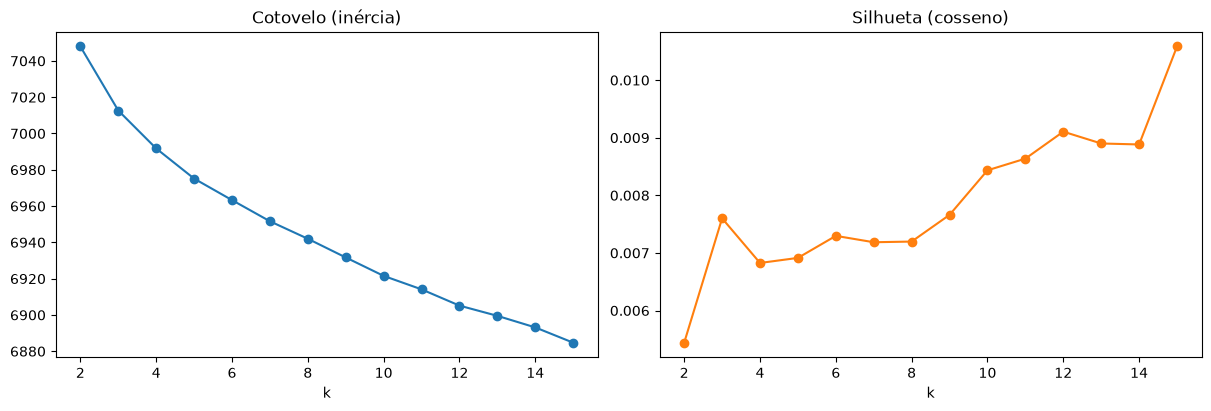

,k,inertia,silhouette
0,2,7047.9517,0.0054
1,3,7012.6518,0.0076
2,4,6991.7588,0.0068
3,5,6975.1525,0.0069
4,6,6963.2974,0.0073
5,7,6951.6361,0.0072
6,8,6941.9942,0.0072
7,9,6931.6960,0.0077
8,10,6921.5400,0.0084
9,11,6914.1178,0.0086


In [4]:
kValues = range(2, 16)
records = []
for k in kValues:
    model = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE).fit(tfidf)
    records.append({
        "k": k, "inertia": model.inertia_,
        "silhouette": silhouette_score(tfidf, model.labels_, metric="cosine", sample_size=3000, random_state=RANDOM_STATE),
    })
kFrame = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
kFrame.plot(x="k", y="inertia", marker="o", ax=axes[0], title="Cotovelo (inércia)", legend=False)
kFrame.plot(x="k", y="silhouette", marker="o", ax=axes[1], title="Silhueta (cosseno)", legend=False, color="tab:orange")
plt.show()
kFrame.round(4)

Como as métricas não apontam um k claro, a escolha é pela **interpretabilidade** das palavras de
cada cluster. Com k=8 os assuntos ficam distintos sem fragmentar demais; altere `N_CLUSTERS` para explorar.

In [5]:
N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE).fit(tfidf)
newsFrame["cluster"] = kmeans.labels_
print("k =", N_CLUSTERS)
newsFrame["cluster"].value_counts().sort_index().rename("newsCount").to_frame()

k = 8


,newsCount
cluster,
0,3001
1,962
2,574
3,346
4,294
5,815
6,347
7,861


## O que cada cluster representa

Palavras de maior peso no centróide de cada cluster.

In [6]:
topWords = pd.DataFrame({
    f"cluster_{cluster:02d}": vocabulary[np.argsort(centroid)[::-1][:12]]
    for cluster, centroid in enumerate(kmeans.cluster_centers_)
}).T
topWords

,0,1,2,3,4,5,6,7,8,9,10,11
cluster_00,impeachment,jornalista,globo,pra,povo,cunha,leia,ontem,informação,brasileiros,através,site
cluster_01,mãe,hospital,morte,corpo,pai,jovem,filha,criança,vítima,mulheres,médico,morreu
cluster_02,odebrecht,palocci,marcelo,propinas,premiada,petrobras,empreiteira,pagamentos,pagamento,delator,esquema,delações
cluster_03,oas,triplex,apartamento,imóvel,trf,guarujá,lavagem,mpf,instância,sentença,condenado,advogados
cluster_04,bolsonaro,candidato,jair,candidatura,alckmin,eleições,psc,pré,eleição,eleitoral,governador,ciro
cluster_05,aécio,gilmar,mendes,joesley,janot,ministros,renan,jbs,relator,pgr,neves,fachin
cluster_06,coreia,kim,nuclear,trump,jong,mísseis,coreano,coréia,pyongyang,nucleares,míssil,guerra
cluster_07,bilhões,mercado,aumento,economia,dados,sociedade,gestão,reforma,medidas,previdência,proposta,áreas


## Correlação com a categoria e com o label

Composição de cada cluster (linhas somam 100%). Serve para ver se os clusters reproduzem as
categorias do corpus, se encontram subtemas dentro delas e se algum assunto concentra mais Fake.

In [7]:
categoryShare = pd.crosstab(newsFrame["cluster"], newsFrame["categoria"], normalize="index")
labelShare = pd.crosstab(newsFrame["cluster"], newsFrame["label"].map({0: "True", 1: "Fake"}), normalize="index")
summary = pd.concat([
    newsFrame["cluster"].value_counts().sort_index().rename("newsCount"),
    categoryShare.idxmax(axis=1).rename("mainCategory"),
    labelShare["Fake"].rename("fakeShare"),
], axis=1)
display(summary.style.format({"fakeShare": "{:.1%}"}))
display(categoryShare.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None))

,newsCount,mainCategory,fakeShare
cluster,,,
0,3001,politica,90.9%
1,962,tv_celebridades,11.0%
2,574,politica,31.0%
3,346,politica,22.3%
4,294,politica,34.7%
5,815,politica,23.1%
6,347,sociedade_cotidiano,49.9%
7,861,politica,5.5%


categoria,ciencia_tecnologia,economia,politica,religiao,sociedade_cotidiano,tv_celebridades
cluster,,,,,,
0,1.5%,0.5%,55.7%,0.9%,15.7%,25.7%
1,2.8%,0.2%,32.2%,1.1%,28.7%,34.9%
2,0.0%,0.7%,86.8%,0.0%,4.9%,7.7%
3,0.0%,0.6%,86.1%,0.0%,3.5%,9.8%
4,0.3%,0.0%,81.0%,0.3%,1.4%,17.0%
5,0.1%,0.1%,82.8%,0.4%,5.4%,11.2%
6,2.0%,0.0%,10.1%,0.3%,83.0%,4.6%
7,3.5%,2.2%,52.8%,0.2%,17.7%,23.6%


## Relação entre clusters

Similaridade de cosseno entre os centróides: valores altos indicam assuntos próximos
(ex.: subtemas de política).

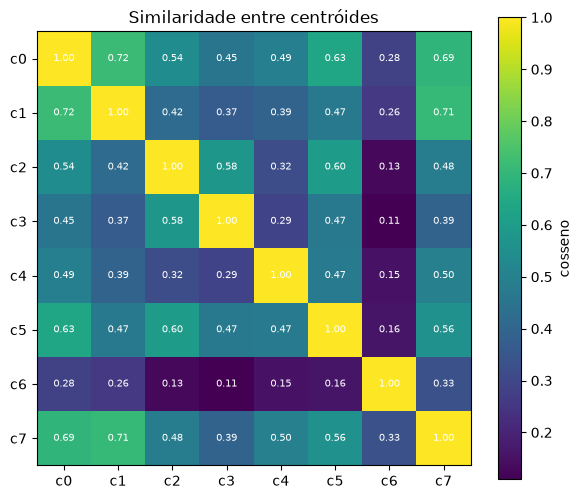

In [8]:
centroidSimilarity = pd.DataFrame(
    cosine_similarity(kmeans.cluster_centers_),
    index=[f"c{c}" for c in range(N_CLUSTERS)], columns=[f"c{c}" for c in range(N_CLUSTERS)],
)
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(centroidSimilarity, cmap="viridis")
ax.set_xticks(range(N_CLUSTERS), centroidSimilarity.columns)
ax.set_yticks(range(N_CLUSTERS), centroidSimilarity.index)
for i in range(N_CLUSTERS):
    for j in range(N_CLUSTERS):
        ax.text(j, i, f"{centroidSimilarity.iat[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white")
fig.colorbar(image, ax=ax, label="cosseno")
ax.set_title("Similaridade entre centróides")
plt.show()

## Visualização 2D

Projeção por SVD truncado (LSA) apenas para visualizar; o K-means foi ajustado no TF-IDF completo.

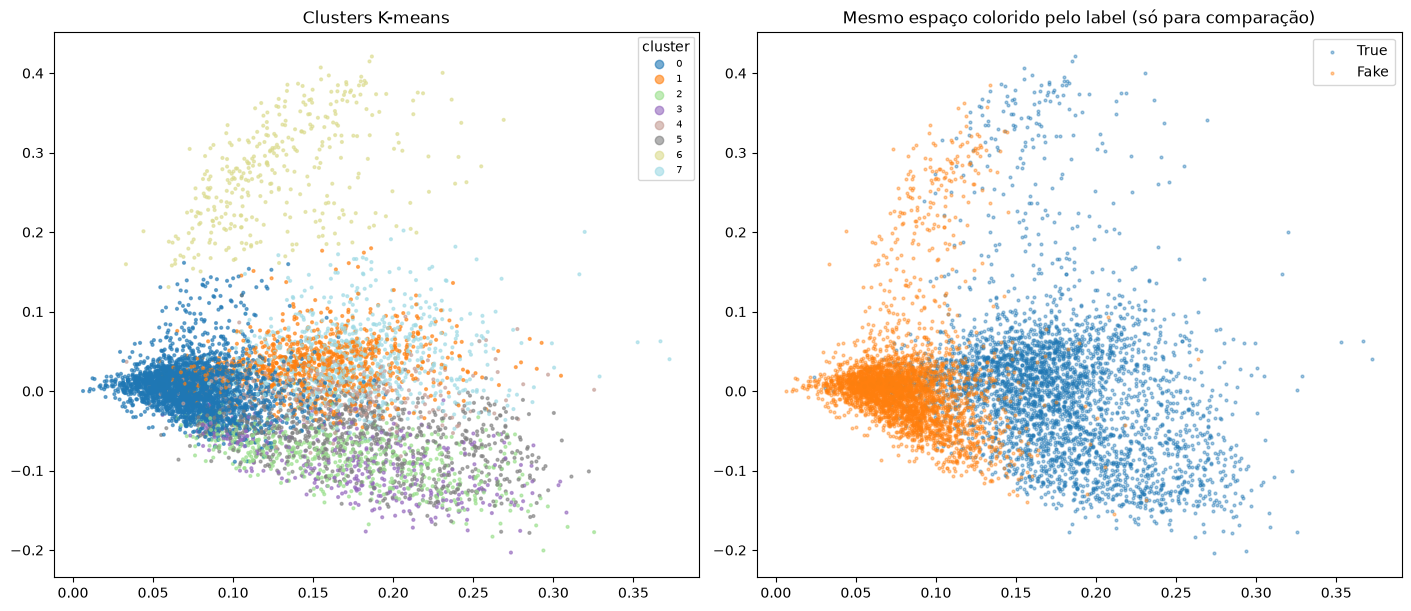

In [9]:
projection = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(tfidf)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
scatter = axes[0].scatter(projection[:, 0], projection[:, 1], c=newsFrame["cluster"], cmap="tab20", s=4, alpha=0.6)
axes[0].legend(*scatter.legend_elements(), title="cluster", fontsize=7, loc="best")
axes[0].set_title("Clusters K-means")
for label, name, color in [(0, "True", "tab:blue"), (1, "Fake", "tab:orange")]:
    mask = newsFrame["label"].eq(label)
    axes[1].scatter(projection[mask, 0], projection[mask, 1], s=4, alpha=0.4, label=name, color=color)
axes[1].legend()
axes[1].set_title("Mesmo espaço colorido pelo label (só para comparação)")
plt.show()

## Exemplos por cluster

As 3 notícias mais próximas de cada centróide (as mais representativas).

In [10]:
distances = kmeans.transform(tfidf)
newsFrame["distanceToCentroid"] = distances[np.arange(len(newsFrame)), newsFrame["cluster"]]
examples = (
    newsFrame.sort_values("distanceToCentroid").groupby("cluster").head(3)
    .sort_values(["cluster", "distanceToCentroid"])
    .assign(preview=lambda frame: frame[TEXT_COLUMN].str.slice(0, 200))
)
pd.set_option("display.max_colwidth", 200)
examples[["cluster", "id", "categoria", "label", "preview"]]

,cluster,id,categoria,label,preview
2682,0,989t,sociedade_cotidiano,0,"Sexta-feira 29 de abril de 2016 Aprendi desde cedo, ainda na minha infância no sertão do rio do Peixe, nos anos 50, a ser do contra, defeito que seria combatido por sal de frutas Eno, receitava u..."
3345,0,145t,politica,0,"Dilma concede entrevista a jornais de 6 países para falar da crise do Brasil\r\n\r\nPresidente conversou por quase 2 horas com correspondentes estrangeiros.\r\nSegundo repórter alemão, ela disse q..."
2583,0,3050t,politica,0,"Logo que a delação dos irmãos Batista veio a público, na noite desta quarta-feira, os petistas não puderam conter a euforia e se lançaram a comemorar. Milicianos do PT e de seus aliados foram pa..."
2925,1,432t,politica,0,"Retrospectiva 2017: confira os principais fatos do ano em Goiás. Mortes dentro de escolas, desaparecimento de técnico e recuperação de pacientes com doenças raras estão entre os fatos marcantes de..."
2336,1,858t,sociedade_cotidiano,0,"'Precisava falar', relatam mulheres que superaram ciclos de violências na Paraíba . Abuso sexual infantil, preconceito no mercado de trabalho, assédio, relacionamento abusivo e violência doméstica..."
3212,1,604t,ciencia_tecnologia,0,"Retrospectiva 2017: os principais fatos do ano no Distrito Federal . Bombeiro que salvou 20 pessoas em incêndio em prédio de madrugada, peça teatral com Jesus trans, manifestações e morte de volun..."
3054,2,2098t,politica,0,"Condenado a 9 anos e 6 meses de prisão por corrupção passiva e lavagem de dinheiro de R$ 2,25 milhões no caso triplex , o ex-presidente Lula ainda é réu em 4 ações penais – uma nas mãos do juiz f..."
3163,2,1594t,politica,0,A Operação Lava Jato e seus desdobramentos ampliam o cerco ao ex-presidente Luiz Inácio Lula da Silva e dificultam ainda mais seu plano de disputar um terceiro mandato na eleição de 2018. Condena...
2184,2,2684t,politica,0,"Delações da Odebrecht apontam propina para pais e filhos, maridos e mulheres, em pagamentos de caixa 2 . Em alguns casos, familiares chegavam a receber dinheiro dos pagamentos não oficiais; boa pa..."
1373,3,1006t,politica,0,"Em decisão unânime, tribunal condena Lula em segunda instância e aumenta pena de 9 para 12 anos. Recurso contra condenação pelo juiz Sérgio Moro foi rejeitado pelos três desembargadores da 8a Turm..."
